Starting RailPulse-AI Predictive Maintenance...

Dataset loaded successfully!
Shape: (5000, 9)

Columns:
['train_id', 'engine_temperature', 'brake_pressure', 'vibration', 'wheel_condition', 'engine_hours', 'last_service_days', 'maintenance_count', 'failure']

First 5 rows:
  train_id  engine_temperature  brake_pressure  vibration  wheel_condition  \
0  TRN5021               91.33           88.74       3.28               55   
1  TRN4020               75.91           93.46       3.34               75   
2  TRN5714               87.09           90.08       5.38               96   
3  TRN5915               62.02           91.54       4.60               85   
4  TRN3186               91.01           87.05       3.15               57   

   engine_hours  last_service_days  maintenance_count  failure  
0          6057                 67                  7        0  
1          5416                257                 11        0  
2          5831                229                  4        0

C:\Users\Dell\AppData\Local\Temp\ipykernel_13904\317160131.py:145: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


Training completed!

PREDICTIVE MAINTENANCE RESULTS
Accuracy: 0.685
Accuracy %: 68.5 %

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.78      0.76      0.77       698
           1       0.48      0.51      0.50       302

    accuracy                           0.69      1000
   macro avg       0.63      0.64      0.63      1000
weighted avg       0.69      0.69      0.69      1000


CONFUSION MATRIX
[[530 168]
 [147 155]]


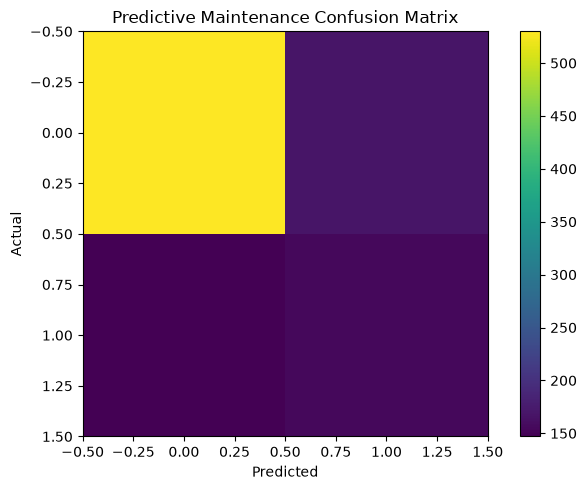


FEATURE IMPORTANCE
           Feature  Importance
 last_service_days      0.1687
   wheel_condition      0.1497
      engine_hours      0.1296
engine_temperature      0.1268
    brake_pressure      0.1227
         vibration      0.1162
          train_id      0.1126
 maintenance_count      0.0738


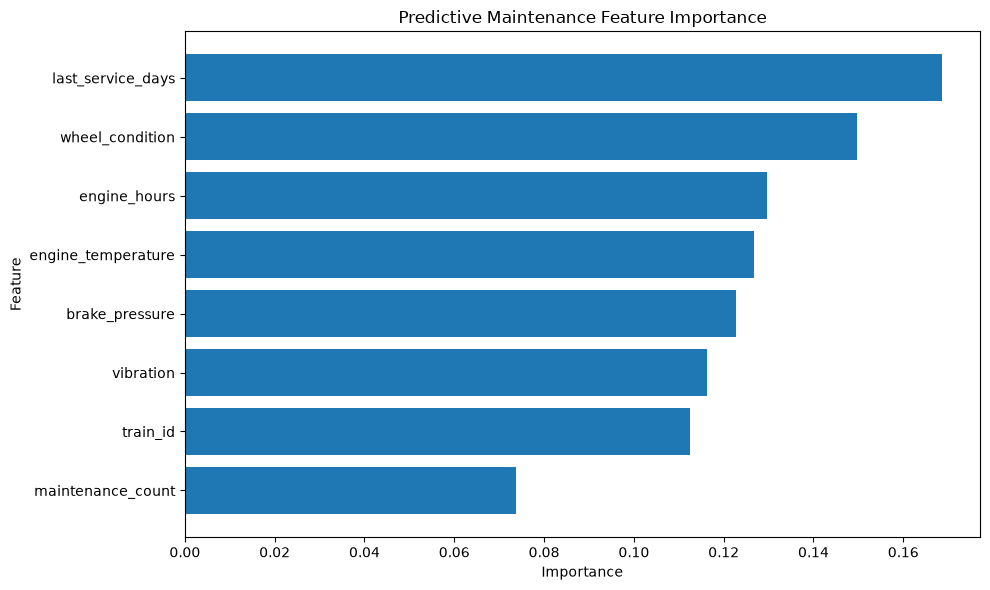


SAMPLE MAINTENANCE PREDICTIONS
 Actual  Predicted
      1          0
      0          0
      0          0
      0          0
      0          0
      0          1
      0          0
      0          0
      0          0
      1          1
      1          0
      0          0
      0          1
      1          1
      0          1

MODEL SAVED
Path: ../models/maintenance/predictive_maintenance.pkl
Predictions saved: ../data/processed/predictive_maintenance_predictions.csv


🎉 07 PREDICTIVE MAINTENANCE COMPLETED!


In [1]:
# ============================================================
# RAILPULSE-AI
# 07 - PREDICTIVE MAINTENANCE
# ============================================================

import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Starting RailPulse-AI Predictive Maintenance...")


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv(
    "../data/raw/maintenance_data.csv"
)

print("\nDataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())


# ============================================================
# 2. DATA INFORMATION
# ============================================================

print("\n======================================")
print("DATA INFORMATION")
print("======================================")

print(df.info())


# ============================================================
# 3. FIND TARGET COLUMN
# ============================================================

possible_targets = [
    "maintenance_required",
    "maintenance",
    "needs_maintenance",
    "failure",
    "failure_risk",
    "target",
    "label"
]

target = None

for col in possible_targets:

    if col in df.columns:
        target = col
        break


if target is None:

    raise ValueError(
        "Maintenance target column not found. "
        "Check the columns printed above."
    )


print("\nTarget column:", target)


# ============================================================
# 4. REMOVE UNNECESSARY COLUMNS
# ============================================================

drop_columns = [
    "id",
    "ID",
    "equipment_id",
    "equipment_name",
    "timestamp"
]

for col in drop_columns:

    if col in df.columns:

        df = df.drop(
            columns=[col]
        )


# ============================================================
# 5. PREPARE TARGET
# ============================================================

y = df[target].copy()

X = df.drop(
    columns=[target]
)


# ============================================================
# 6. ENCODE TARGET IF CATEGORICAL
# ============================================================

target_encoder = None

if y.dtype == "object":

    target_encoder = LabelEncoder()

    y = target_encoder.fit_transform(
        y.astype(str)
    )

else:

    y = pd.to_numeric(
        y,
        errors="coerce"
    )


# ============================================================
# 7. ENCODE CATEGORICAL FEATURES
# ============================================================

categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()


feature_encoders = {}

for col in categorical_columns:

    encoder = LabelEncoder()

    X[col] = encoder.fit_transform(
        X[col].astype(str)
    )

    feature_encoders[col] = encoder


# ============================================================
# 8. CONVERT NUMERIC DATA
# ============================================================

for col in X.columns:

    X[col] = pd.to_numeric(
        X[col],
        errors="coerce"
    )


# ============================================================
# 9. HANDLE INFINITE VALUES
# ============================================================

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# 10. HANDLE MISSING VALUES
# ============================================================

for col in X.columns:

    if X[col].isna().any():

        X[col] = X[col].fillna(
            X[col].median()
        )


# ============================================================
# 11. REMOVE INVALID TARGET ROWS
# ============================================================

if isinstance(y, pd.Series):

    valid_rows = y.notna()

    X = X.loc[valid_rows]

    y = y.loc[valid_rows]


# ============================================================
# 12. CHECK PREPARED DATA
# ============================================================

print("\n======================================")
print("PREPARED DATA")
print("======================================")

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")

for feature in X.columns:

    print("-", feature)

print("\nTarget distribution:")

print(
    pd.Series(y).value_counts()
)


# ============================================================
# 13. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y if len(
        pd.Series(y).unique()
    ) > 1 else None
)


print("\n======================================")
print("TRAIN TEST SPLIT")
print("======================================")

print(
    "Training data:",
    X_train.shape
)

print(
    "Testing data:",
    X_test.shape
)


# ============================================================
# 14. RANDOM FOREST CLASSIFIER
# ============================================================

model = RandomForestClassifier(

    n_estimators=200,

    max_depth=15,

    random_state=42,

    n_jobs=-1,

    class_weight="balanced"
)


print("\nTraining Random Forest...")

model.fit(
    X_train,
    y_train
)


print("Training completed!")


# ============================================================
# 15. PREDICTIONS
# ============================================================

y_pred = model.predict(
    X_test
)


# ============================================================
# 16. ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)


print("\n======================================")
print("PREDICTIVE MAINTENANCE RESULTS")
print("======================================")

print(
    "Accuracy:",
    round(accuracy, 4)
)

print(
    "Accuracy %:",
    round(accuracy * 100, 2),
    "%"
)


# ============================================================
# 17. CLASSIFICATION REPORT
# ============================================================

print("\n======================================")
print("CLASSIFICATION REPORT")
print("======================================")

print(
    classification_report(
        y_test,
        y_pred
    )
)


# ============================================================
# 18. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n======================================")
print("CONFUSION MATRIX")
print("======================================")

print(cm)


plt.figure(
    figsize=(7, 5)
)

plt.imshow(cm)

plt.title(
    "Predictive Maintenance Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.colorbar()

plt.tight_layout()

plt.show()


# ============================================================
# 19. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        model.feature_importances_

})


importance = importance.sort_values(

    by="Importance",

    ascending=False

)


print("\n======================================")
print("FEATURE IMPORTANCE")
print("======================================")

print(
    importance.round(4).to_string(
        index=False
    )
)


plt.figure(
    figsize=(10, 6)
)

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Predictive Maintenance Feature Importance"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()


# ============================================================
# 20. SAMPLE PREDICTIONS
# ============================================================

sample_results = pd.DataFrame({

    "Actual":
        y_test.values,

    "Predicted":
        y_pred

})


print("\n======================================")
print("SAMPLE MAINTENANCE PREDICTIONS")
print("======================================")

print(
    sample_results.head(15).to_string(
        index=False
    )
)


# ============================================================
# 21. SAVE MODEL
# ============================================================

model_folder = (
    "../models/maintenance"
)

os.makedirs(
    model_folder,
    exist_ok=True
)


model_path = (
    model_folder +
    "/predictive_maintenance.pkl"
)


# Save model + encoders + feature names
model_package = {

    "model": model,

    "feature_names":
        X.columns.tolist(),

    "feature_encoders":
        feature_encoders,

    "target_encoder":
        target_encoder

}


joblib.dump(
    model_package,
    model_path
)


print("\n======================================")
print("MODEL SAVED")
print("======================================")

print(
    "Path:",
    model_path
)


# ============================================================
# 22. SAVE PREDICTIONS
# ============================================================

prediction_folder = (
    "../data/processed"
)

os.makedirs(
    prediction_folder,
    exist_ok=True
)


prediction_path = (
    prediction_folder +
    "/predictive_maintenance_predictions.csv"
)


sample_results.to_csv(

    prediction_path,

    index=False

)


print(
    "Predictions saved:",
    prediction_path
)


# ============================================================
# 23. FINAL STATUS
# ============================================================

print("\n")
print("======================================")
print("🎉 07 PREDICTIVE MAINTENANCE COMPLETED!")
print("======================================")